In [ ]:
from pathlib import Path
import datetime as dt
import xarray as xr
import numpy as np
import pandas as pd
import dask
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.cm import get_cmap
from matplotlib import pyplot as plt

In [ ]:
resolution = 4         # 4 or 12 km
projdir = Path().resolve().parents[0]

datadir = projdir / "evaluation/working"
chunking = {
    4: ['auto', 'auto'],
    12: ['auto', 'auto']
}

In [ ]:
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)

/tmp/ipykernel_1696413/3081670720.py:1: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(


### Explore wind data one resolution at a time

In [ ]:
winddatapth = datadir / f"windavg_monthly_{resolution}km.nc"
windDS = xr.open_dataset(winddatapth, chunks='auto')
windDS

In [ ]:
wind = xr.open_dataarray(winddatapth, chunks='auto')
wind

<xarray.DataArray 'wspd10' (time: 480, south_north: 450, west_east: 420)> Size: 363MB
dask.array<open_dataset-wspd10, shape=(480, 450, 420), dtype=float32, chunksize=(320, 300, 280), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
  * time     (time) datetime64[ns] 4kB 1981-01-31 1981-02-28 ... 2020-12-31
Dimensions without coordinates: south_north, west_east

In [ ]:
wind_byseason = wind.groupby("time.season").mean("time")
wind_byseason.sel(season='DJF')

<xarray.DataArray 'wspd10' (south_north: 450, west_east: 420)> Size: 756kB
dask.array<getitem, shape=(450, 420), dtype=float32, chunksize=(300, 280), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 756kB dask.array<chunksize=(450, 420), meta=np.ndarray>
    season   <U3 12B 'DJF'
Dimensions without coordinates: south_north, west_east

Text(0.5, 1.0, 'DJF average hourly windspeed (m/s)')

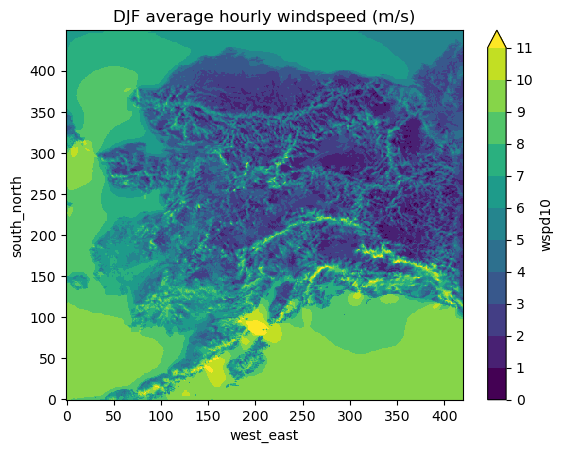

In [ ]:
levels = list(range(12))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title(f"{testssn} average hourly windspeed (m/s)")

/tmp/ipykernel_3136001/4045135598.py:1: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


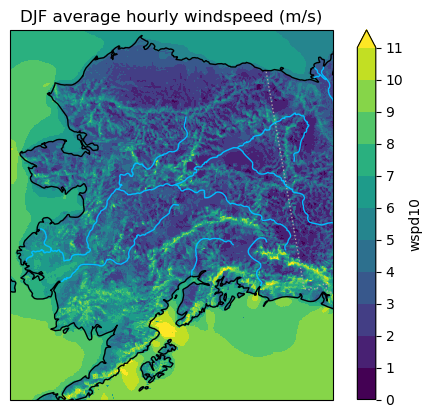

In [ ]:


ax = plt.axes(projection=projection)
wind_byseason.sel(season=testssn).plot(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"{testssn} average hourly windspeed (m/s)")
ax.set_extent([-164.35, -140.3, 55.5, 71.3])
# ax.set_extent([-180, -130, 48, 75])

Text(0.5, 1.0, 'DJF average hourly windspeed (m/s)')

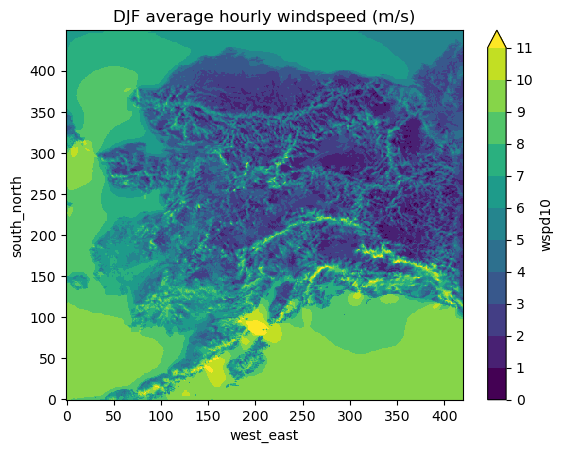

In [ ]:
levels = list(range(12))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title(f"{testssn} average hourly windspeed (m/s)")

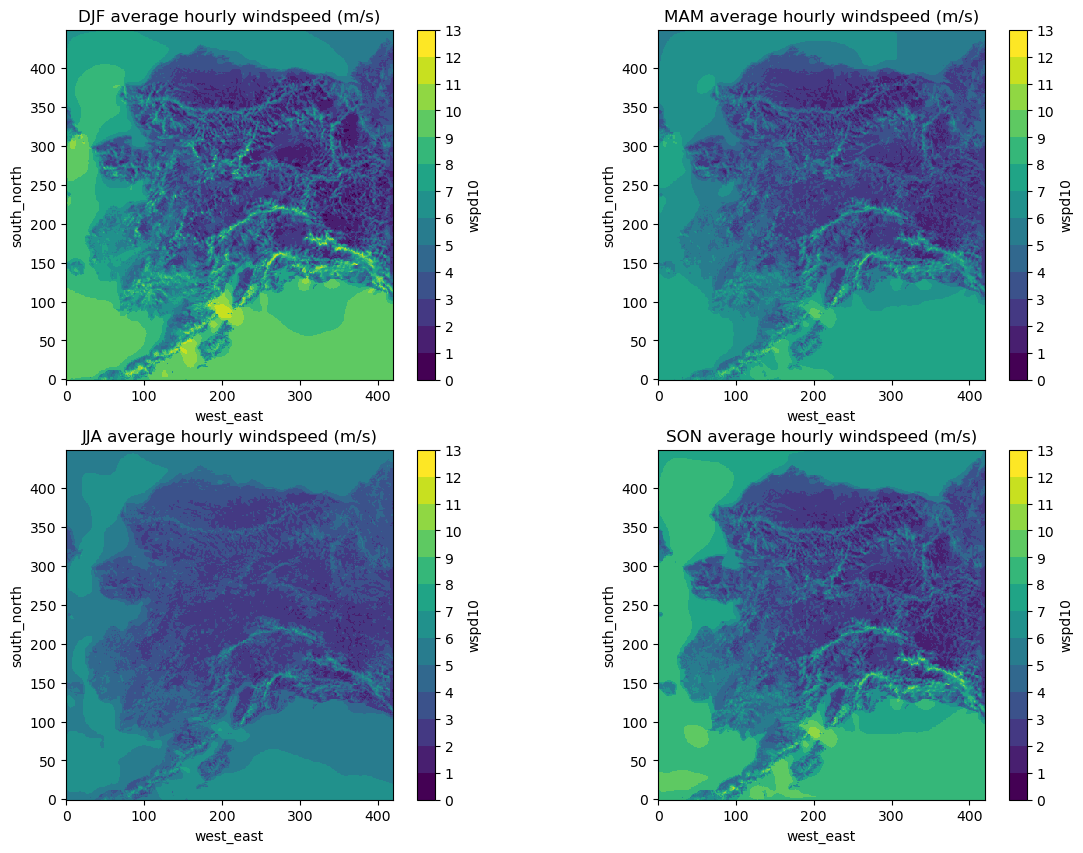

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
for ssn, ax in zip(seasons, axes.flatten()):
    wind_byseason.sel(season=ssn).plot(
        levels=levels, cbar_kwargs={'ticks': levels},
        ax=ax)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} average hourly windspeed (m/s)")

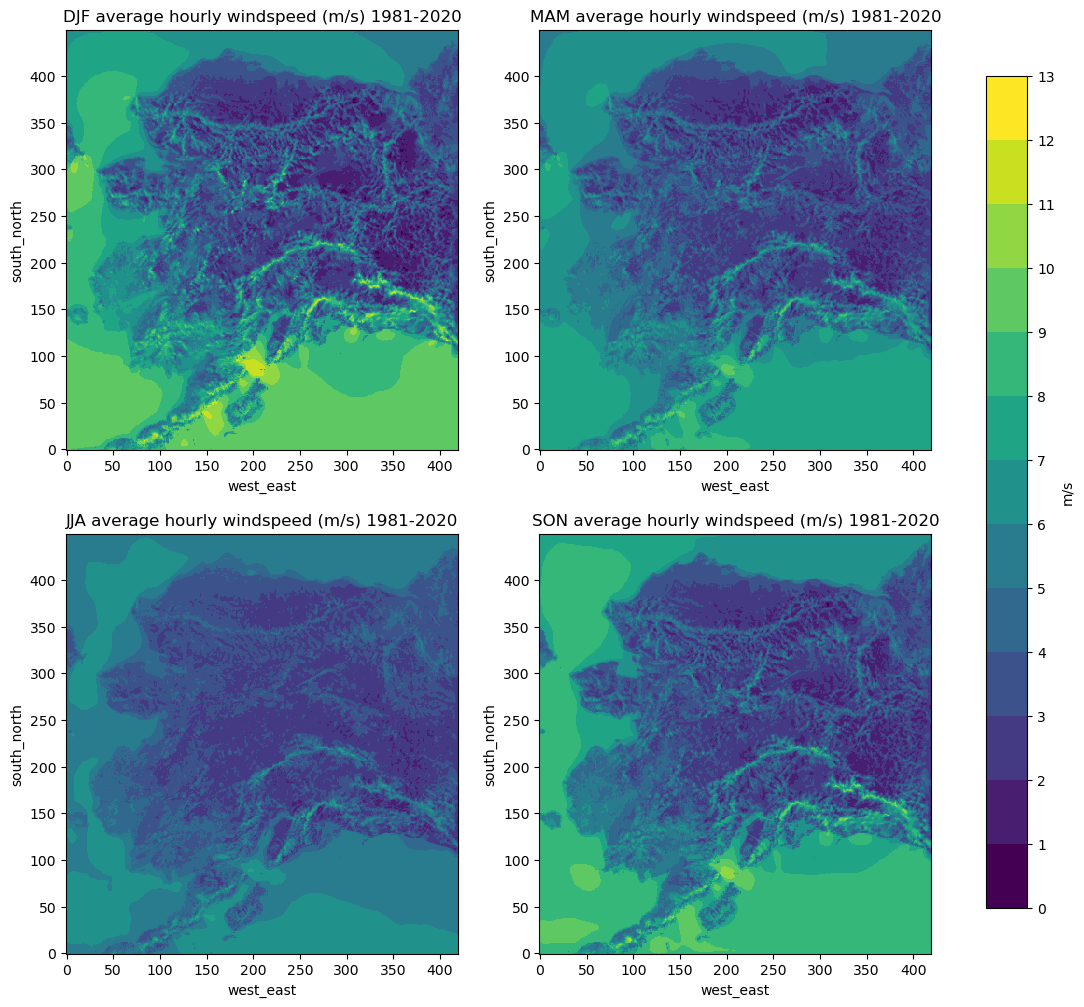

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        ax=ax, add_colorbar=False)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} average hourly windspeed (m/s) 1981-2020")
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, shrink=0.9)
cbar.set_label('m/s')

/tmp/ipykernel_3136001/749954046.py:3: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/

Text(0.5, 0.98, 'Average hourly windspeed (m/s) 1981-2020')

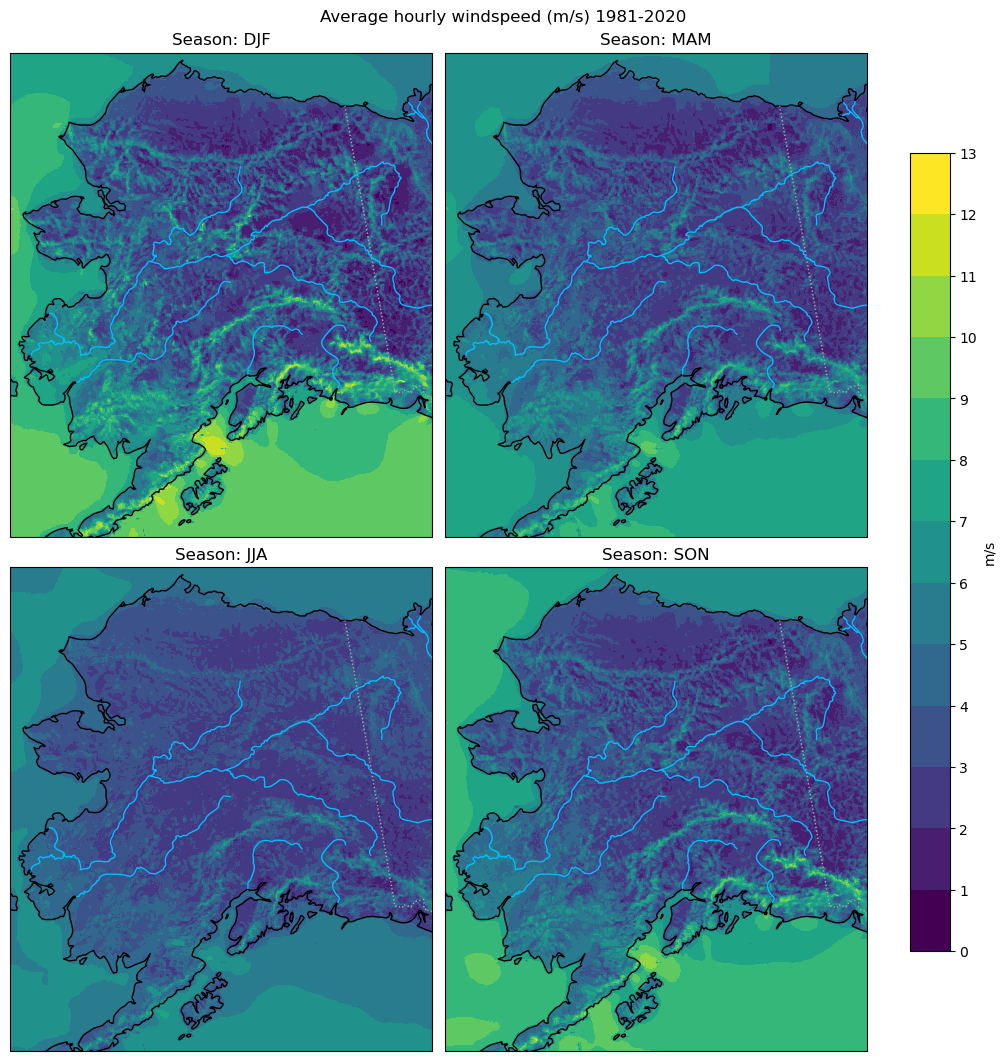

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)
extent = [-164.35, -140.3, 55.5, 71.3]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10.5), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        transform=ccrs.PlateCarree(),
        ax=ax,
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines()
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle("Average hourly windspeed (m/s) 1981-2020")
# fig.subplots_adjust(wspace=0.2, hspace=0.2)


In [ ]:
fig.get_figwidth()

10.0

In [ ]:
wind_mean_4 = wind.mean(dim='time')
wind_mean_4.compute()

<xarray.DataArray 'wspd10' (south_north: 450, west_east: 420)> Size: 756kB
array([[7.801707 , 7.7721763, 7.7407584, ..., 7.9774413, 7.9847064,
        7.990318 ],
       [7.84424  , 7.8383656, 7.8180084, ..., 7.9864163, 7.9936676,
        7.9902773],
       [7.8834925, 7.884845 , 7.875498 , ..., 7.9940457, 7.9982524,
        7.9901295],
       ...,
       [6.1648483, 6.2019715, 6.239809 , ..., 5.560975 , 5.4880285,
        5.4075823],
       [6.1438355, 6.17965  , 6.2151213, ..., 5.556628 , 5.481674 ,
        5.3956914],
       [6.1350994, 6.1639566, 6.1969743, ..., 5.5680604, 5.502933 ,
        5.4207997]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
Dimensions without coordinates: south_north, west_east

In [ ]:
wind_mean_12 = wind.mean(dim='time')
wind_mean_12.compute()

<xarray.DataArray 'wspd10' (south_north: 450, west_east: 420)> Size: 756kB
array([[7.801707 , 7.7721763, 7.7407584, ..., 7.9774413, 7.9847064,
        7.990318 ],
       [7.84424  , 7.8383656, 7.8180084, ..., 7.9864163, 7.9936676,
        7.9902773],
       [7.8834925, 7.884845 , 7.875498 , ..., 7.9940457, 7.9982524,
        7.9901295],
       ...,
       [6.1648483, 6.2019715, 6.239809 , ..., 5.560975 , 5.4880285,
        5.4075823],
       [6.1438355, 6.17965  , 6.2151213, ..., 5.556628 , 5.481674 ,
        5.3956914],
       [6.1350994, 6.1639566, 6.1969743, ..., 5.5680604, 5.502933 ,
        5.4207997]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
Dimensions without coordinates: south_north, west_east

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

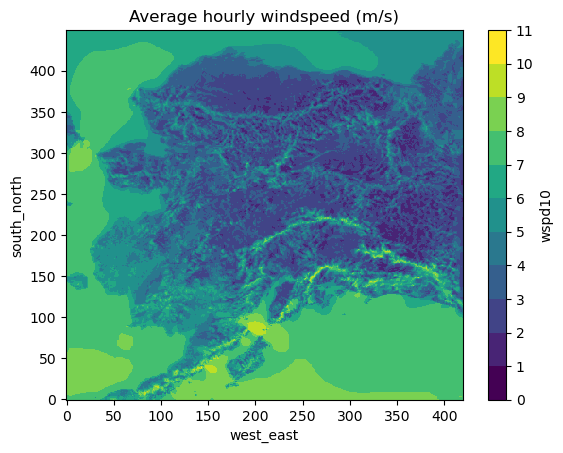

In [ ]:
levels = list(range(12))
wind_mean_4.plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title("Average hourly windspeed (m/s)")

### Zoom in on areas of interest around weather stations

In [ ]:
locations = {
        'Bethel': {'lon': -161.82932, 'lat': 60.78497, 'extent': [-162.4, -161.05, 60.5, 60.95]},
        'Fairbanks': {'lon': -147.87605, 'lat': 64.80309, 'extent': [-148.5, -146.85, 64.5, 65]},
        'Anchorage': {'lon': -150.02771, 'lat': 61.16916, 'extent': [-151, -149, 60.9, 61.6]},
        'Utqiaġvik':  {'lon': -156.73938, 'lat': 71.28703, 'extent':[-157.5, -155.5, 71, 71.5]},
    }

In [ ]:
resolution = 4
winddatapth = datadir / f"windavg_monthly_{resolution}km.nc"
wind = xr.open_dataarray(winddatapth, chunks='auto')
wind_mean_4 = wind.mean(dim='time')
wind_mean_4.compute()

<xarray.DataArray 'wspd10' (south_north: 450, west_east: 420)> Size: 756kB
array([[7.801707 , 7.7721763, 7.7407584, ..., 7.9774413, 7.9847064,
        7.990318 ],
       [7.84424  , 7.8383656, 7.8180084, ..., 7.9864163, 7.9936676,
        7.9902773],
       [7.8834925, 7.884845 , 7.875498 , ..., 7.9940457, 7.9982524,
        7.9901295],
       ...,
       [6.1648483, 6.2019715, 6.239809 , ..., 5.560975 , 5.4880285,
        5.4075823],
       [6.1438355, 6.17965  , 6.2151213, ..., 5.556628 , 5.481674 ,
        5.3956914],
       [6.1350994, 6.1639566, 6.1969743, ..., 5.5680604, 5.502933 ,
        5.4207997]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
Dimensions without coordinates: south_north, west_east

In [ ]:
resolution = 12
winddatapth = datadir / f"windavg_monthly_{resolution}km.nc"
wind = xr.open_dataarray(winddatapth, chunks='auto')
wind_mean_12 = wind.mean(dim='time')
wind_mean_12.compute()

<xarray.DataArray 'wspd10' (south_north: 204, west_east: 264)> Size: 215kB
array([[8.660764 , 8.67181  , 8.662787 , ..., 7.62063  , 7.6113157,
        7.5986423],
       [8.698404 , 8.7472925, 8.730851 , ..., 7.6446633, 7.616762 ,
        7.5831075],
       [8.713218 , 8.77561  , 8.771167 , ..., 7.6305017, 7.5850754,
        7.537311 ],
       ...,
       [2.1873472, 2.4399107, 2.418032 , ..., 3.7336397, 3.9828978,
        4.2104654],
       [2.0656714, 2.163661 , 1.9793795, ..., 3.616826 , 3.7999525,
        4.0999746],
       [2.0886   , 1.7930793, 1.5858988, ..., 3.7445414, 3.8336852,
        3.9922402]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 215kB -174.4 -174.2 ... -108.3
    XLAT     (south_north, west_east) float32 215kB 50.55 50.59 ... 69.67 69.59
Dimensions without coordinates: south_north, west_east

Raw plot around PABR

(-0.5, 39.5, -0.5, 29.5)

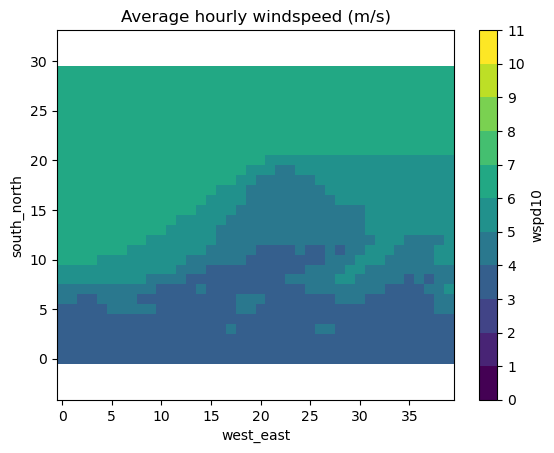

In [ ]:
levels = list(range(12))
wind_mean_4[410:440, 150:190].plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title("Average hourly windspeed (m/s)")
plt.axis('equal')

In [ ]:
def plot_windmean_grid(wind_mean, ax, lat, lon, extent=[-157.5, -155.5, 71, 71.5], colorbar=False):
    wind_mean.plot.pcolormesh(
        levels=levels, 
        add_colorbar=colorbar,
        transform=ccrs.PlateCarree(),
        ax=ax,
        cmap='viridis',
        edgecolor='darkgrey', linewidth=0.05, linestyle=':',
        x="XLONG", y="XLAT",
    )

    ax.plot(lon, lat, 'P', color='crimson', markersize=6, transform=ccrs.PlateCarree())
    ax.plot(np.round(4*lon)/4,np.round(4*lat)/4, 'o', color='gold', markersize=7, transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    ax.add_feature(cf.RIVERS, color='deepskyblue', lw=2)
    ax.set_extent(extent)

def plot_windmean_grid_forlocation(wind_mean, ax, location, colorbar=False):
    lat = locations[location]['lat']
    lon = locations[location]['lon']
    extent = locations[location]['extent']
    plot_windmean_grid(wind_mean, ax, lat, lon, extent, colorbar=colorbar)

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


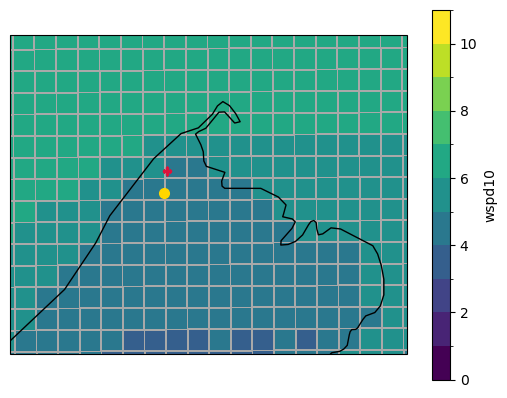

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_4, ax, 'Utqiaġvik', colorbar=True)   

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


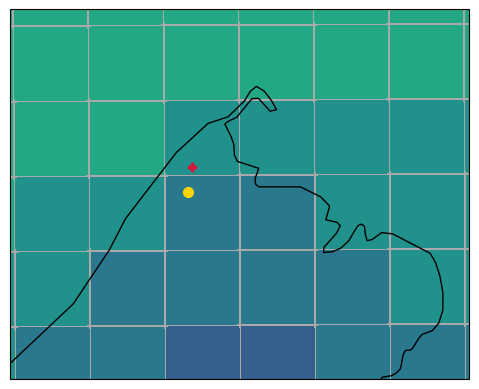

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_12, ax, 'Utqiaġvik')  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


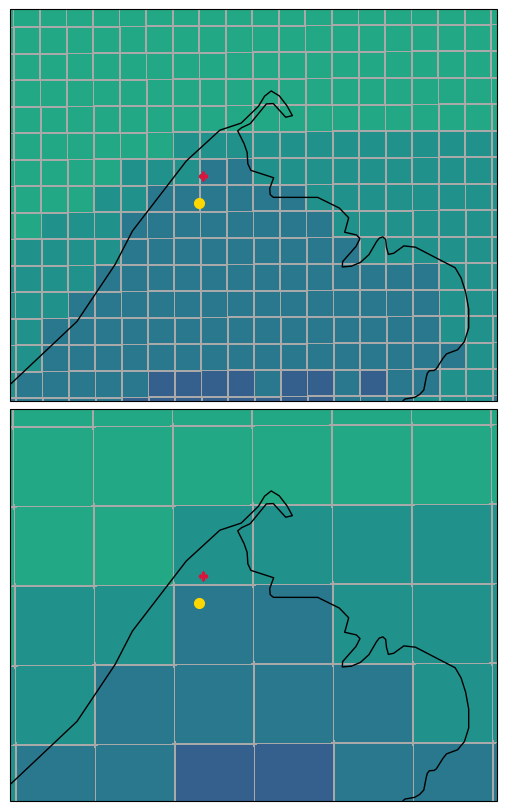

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(5, 8), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)

plot_windmean_grid_forlocation(wind_mean_4, axes[0], 'Utqiaġvik')   
plot_windmean_grid_forlocation(wind_mean_12, axes[1], 'Utqiaġvik')  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


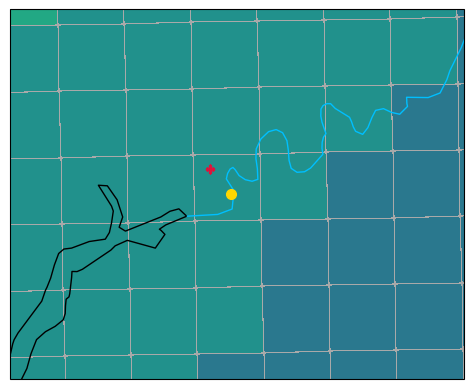

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_12, ax, 'Bethel')  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


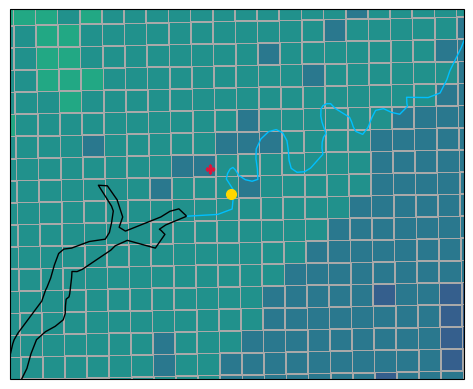

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_4, ax, 'Bethel')  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


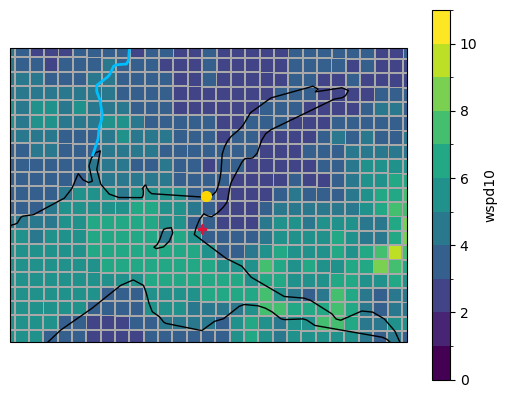

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_4, ax, 'Anchorage', colorbar=True)  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


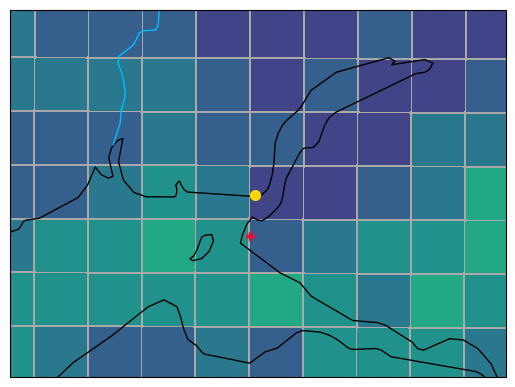

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_12, ax, 'Anchorage')  

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


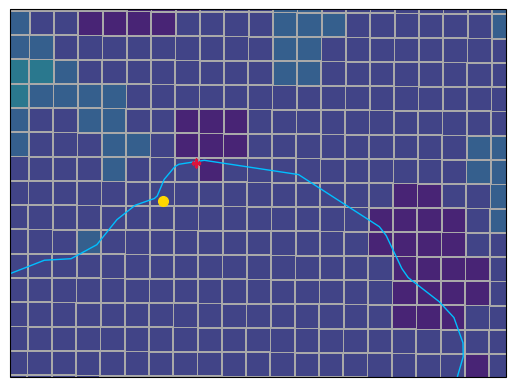

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_4, ax, 'Fairbanks') 

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


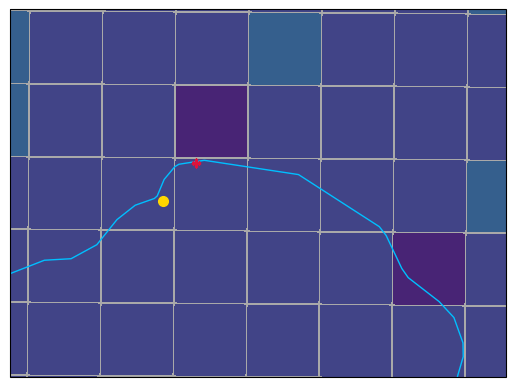

In [ ]:
ax = plt.axes(projection=projection)
plot_windmean_grid_forlocation(wind_mean_12, ax, 'Fairbanks') 

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will 

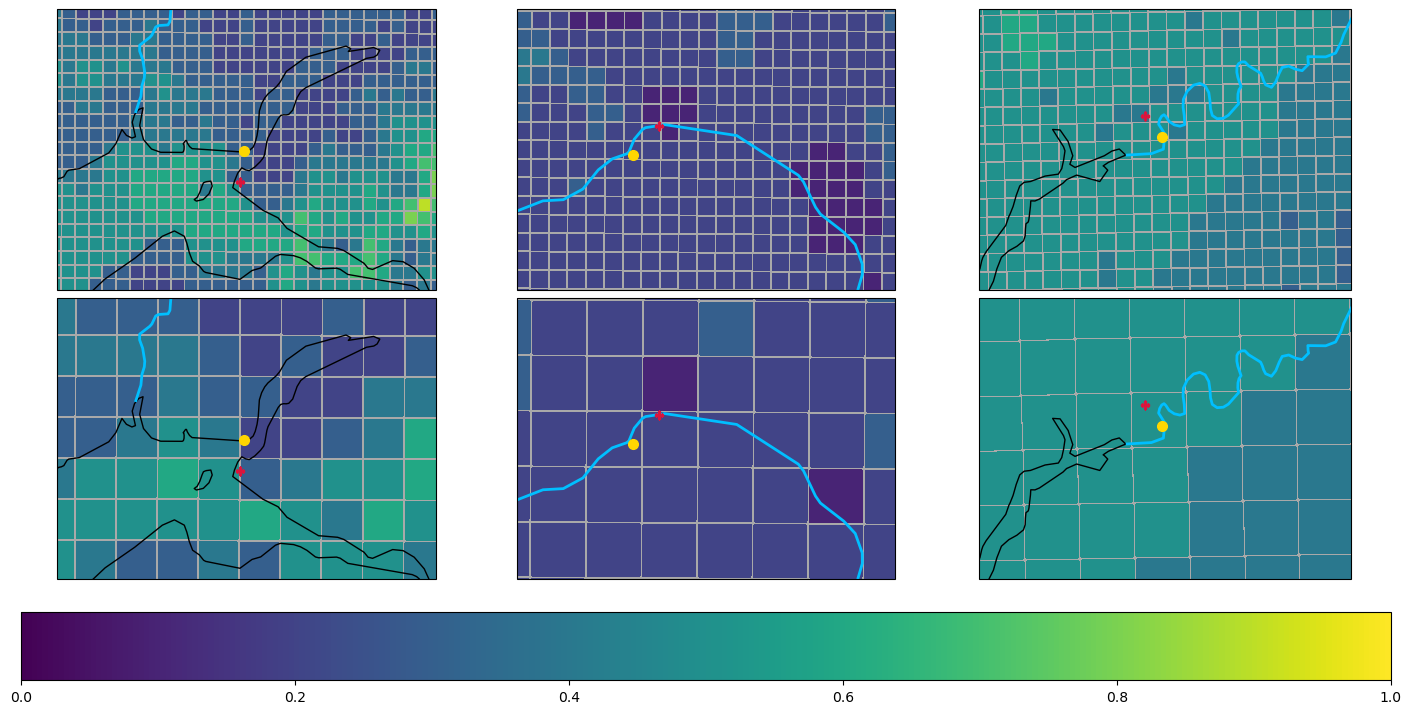

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)

plot_windmean_grid_forlocation(wind_mean_4, axes[0][0], 'Anchorage')   
plot_windmean_grid_forlocation(wind_mean_12, axes[1][0], 'Anchorage') 
plot_windmean_grid_forlocation(wind_mean_4, axes[0][1], 'Fairbanks')   
plot_windmean_grid_forlocation(wind_mean_12, axes[1][1], 'Fairbanks') 
plot_windmean_grid_forlocation(wind_mean_4, axes[0][2], 'Bethel')   
im = plot_windmean_grid_forlocation(wind_mean_12, axes[1][2], 'Bethel') 
fig.colorbar(im, ax=axes, 
             orientation='horizontal')

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


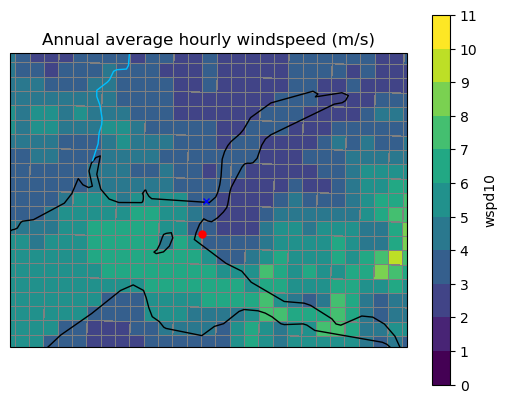

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-150.02771, 61.169163, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.plot(-150.0, 61.25, 'x', color='blue', markersize=5, transform=ccrs.PlateCarree())

# ax.plot(210.0-360,61.25, 'x', color='blue', markersize=5, transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-151, -149, 60.9, 61.6])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


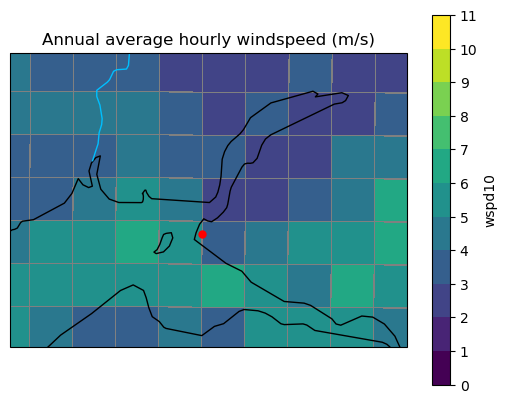

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-150.02771, 61.169163, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-151, -149, 60.9, 61.6])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


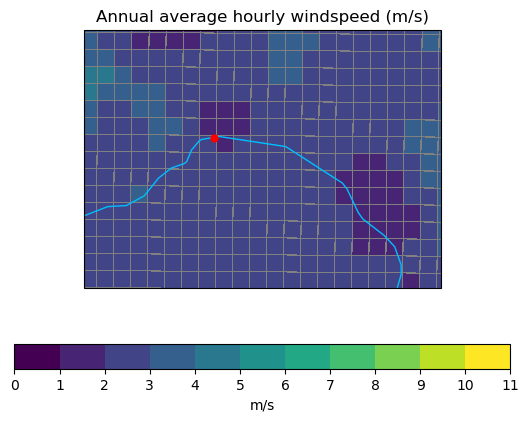

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels, 'orientation': 'horizontal', 'label': 'm/s'},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-147.87605, 64.80309, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-148.5, -146.8, 64.5, 65])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


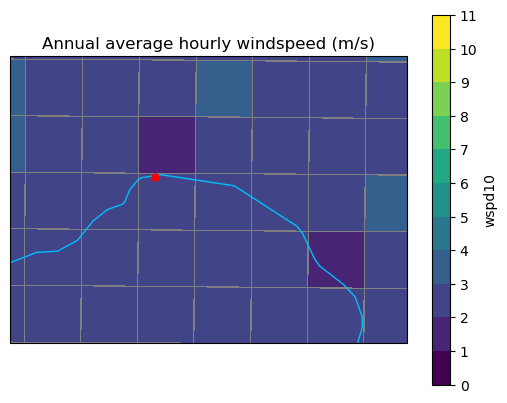

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-147.87605,64.80309, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-148.5, -146.8, 64.5, 65])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


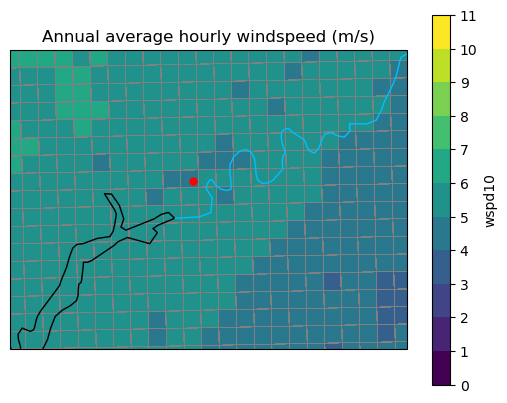

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-161.82932,60.78497, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-162.5, -161, 60.5, 61])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


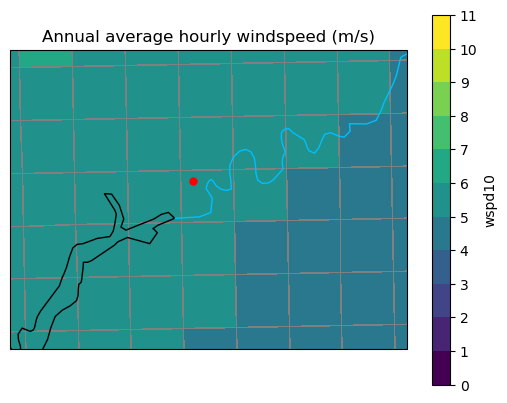

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-161.82932,60.78497, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-162.5, -161, 60.5, 61])

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

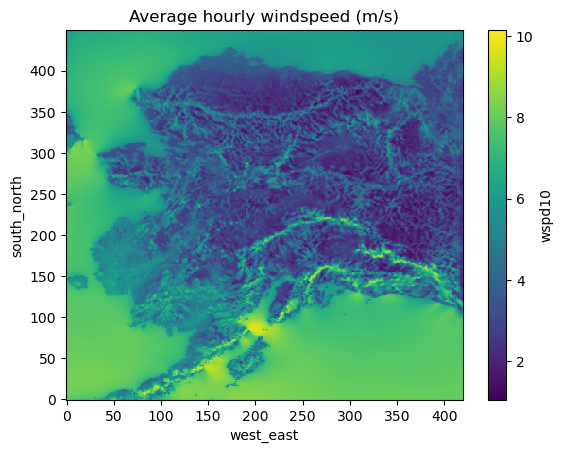

In [ ]:
wind_mean.plot()
plt.title("Average hourly windspeed (m/s)")

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

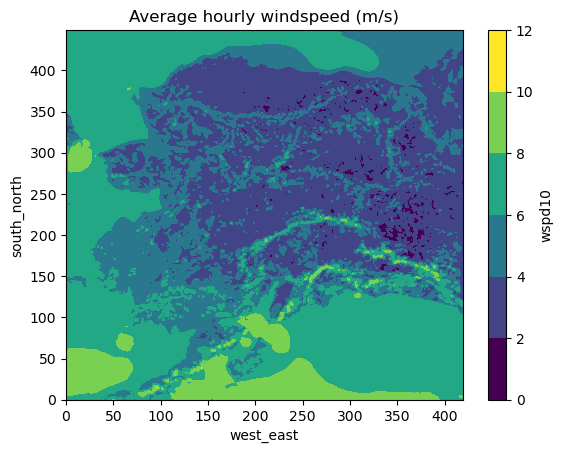

In [ ]:
wind_mean.plot.contourf( )
plt.title("Average hourly windspeed (m/s)")

Open _one_ data file to retrieve the correct i,j value

In [ ]:
testpath = next(datadir.rglob("*.nc"))

In [ ]:
testpath

PosixPath('/import/beegfs/CMIP6/wrf_era5/04km/1982/era5_wrf_dscale_4km_1982-08-21.nc')

In [ ]:
xloc, yloc = getarrayindices(test_lat, test_lon, testpath, l1norm=False)

xloc, yloc

(251, 261)